# Análisis de Cohortes

**Entendiendo el comportamiento  lo largo de los meses**

Es útil para entender cómo evoluciona el valor de los clientes a lo largo del tiempo y evaluar la efectividad de las acciones sobre segmentos específicos.

Esta técnica grupa a los clientes en función de un atributo común (generalmente el momento en que realizaron una acción, como su primera compra o registro) para analizar su comportamiento a lo largo del tiempo. El objetivo es identificar patrones de retención, engagement o deserción dentro de estos grupos, llamados cohortes.

## Importación de librerías y carga de datos

In [18]:
# Importación de librerías
import pandas as pd
ruta_absoluta = r'C:/Users/armil/Desktop/Begoña/data d4bs/CASOS/CASO FINAL 2/00 Datasets/productos_final.csv'

productos = pd.read_csv(ruta_absoluta, parse_dates=['Fecha'])

In [19]:
productos.head()

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta
0,1,2023-01-21,3442,0H2,6OUVC,7.64,4.0,10.50,42.00
1,1,2023-01-21,3442,N8U,CEBU8,4.57,4.0,5.79,23.16
2,2,2023-03-24,14177,TVL,2SLS0,4.60,3.0,7.77,23.31
3,2,2023-06-19,30451,F9B,GZ6VU,9.04,3.0,15.00,45.00
4,3,2023-01-01,90,LPF,Y1M2E,3.37,4.0,4.08,16.32


## Asignar el mes de cada transacción

Creamos una nueva columna que contiene solo el mes y el año de cada transacción.

In [20]:
# Crear la columna 'MesTransaccion' a partir de 'Fecha' en formato Period (mes y año)
productos['MesTransaccion'] = productos['Fecha'].dt.to_period('M')

# Revisamos las primeras filas para confirmar
productos[['ID_Cliente', 'Fecha', 'MesTransaccion']].head()

,ID_Cliente,Fecha,MesTransaccion
0,1,2023-01-21,2023-01
1,1,2023-01-21,2023-01
2,2,2023-03-24,2023-03
3,2,2023-06-19,2023-06
4,3,2023-01-01,2023-01


In [21]:
productos.head()

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta,MesTransaccion
0,1,2023-01-21,3442,0H2,6OUVC,7.64,4.0,10.50,42.00,2023-01
1,1,2023-01-21,3442,N8U,CEBU8,4.57,4.0,5.79,23.16,2023-01
2,2,2023-03-24,14177,TVL,2SLS0,4.60,3.0,7.77,23.31,2023-03
3,2,2023-06-19,30451,F9B,GZ6VU,9.04,3.0,15.00,45.00,2023-06
4,3,2023-01-01,90,LPF,Y1M2E,3.37,4.0,4.08,16.32,2023-01


In [22]:
# Revisamos que mantenemos el mismo número de clientes
productos.ID_Cliente.nunique()

20688

In [23]:
# Sacamos una vista ordenada de los datos por Cliente y MesTransaccion
productos.sort_values(by=['ID_Cliente','MesTransaccion']).head(20)

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta,MesTransaccion
0,1,2023-01-21,3442,0H2,6OUVC,7.64,4.0,10.50,42.00,2023-01
1,1,2023-01-21,3442,N8U,CEBU8,4.57,4.0,5.79,23.16,2023-01
2,2,2023-03-24,14177,TVL,2SLS0,4.60,3.0,7.77,23.31,2023-03
3,2,2023-06-19,30451,F9B,GZ6VU,9.04,3.0,15.00,45.00,2023-06
4,3,2023-01-01,90,LPF,Y1M2E,3.37,4.0,4.08,16.32,2023-01
5,3,2023-01-01,90,TW8,WHV3G,1.15,3.0,1.38,4.14,2023-01
6,3,2023-01-01,90,TW8,WALAE,0.89,3.0,1.38,4.14,2023-01
7,4,2023-07-11,34042,69B,APEJQ,3.48,5.0,6.69,33.45,2023-07
8,4,2023-11-09,54618,YMJ,QR49F,5.31,4.0,7.37,29.48,2023-11
9,4,2023-11-09,54618,29A,RBNO8,5.67,4.0,8.65,34.60,2023-11


**Explicación rápida del método trasform() y su diferencia con respecto al método agg()**

- **agg**: Permite realizar agregaciones a nivel de grupo, como sumas, promedios, o en el caso anterior, calcular la Recency usando la última fecha de cada cliente. agg devuelve un DataFrame más pequeño porque resume los datos de cada grupo.

- **transform**: Aplica una función a cada grupo, pero devuelve un resultado con la misma forma que el DataFrame original. Es útil cuando queremos aplicar una transformación y mantener el mismo número de filas que en el original.

In [24]:
productos.groupby('ID_Cliente')['MesTransaccion'].agg('min')
#Calcula el primer mes (el mínimo) en el que ese cliente aparece
#Devuelve una fila por cliente

ID_Cliente
1        2023-01
2        2023-03
3        2023-01
4        2023-07
5        2023-02
          ...   
22621    2023-12
22622    2023-12
22623    2023-12
22624    2023-12
22625    2023-12
Name: MesTransaccion, Length: 20688, dtype: period[M]

In [25]:
productos.groupby('ID_Cliente')['MesTransaccion'].transform('min')
#Calcula el mismo mínimo, pero…Lo devuelve repetido en todas las filas del cliente

0        2023-01
1        2023-01
2        2023-03
3        2023-03
4        2023-01
          ...   
78261    2023-11
78262    2023-10
78263    2023-06
78264    2023-10
78265    2023-08
Name: MesTransaccion, Length: 78266, dtype: period[M]

## Añadir el MesCohorte

El mes en el que hace la primera compra

In [26]:
# Calculo la nueva variable
productos['MesCohorte'] = productos.groupby('ID_Cliente')['MesTransaccion'].transform('min')

In [27]:
# Sacamos una vista ordenada de los datos por Cliente y MesTransaccion
productos.sort_values(by=['ID_Cliente','MesTransaccion']).head(20)

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta,MesTransaccion,MesCohorte
0,1,2023-01-21,3442,0H2,6OUVC,7.64,4.0,10.50,42.00,2023-01,2023-01
1,1,2023-01-21,3442,N8U,CEBU8,4.57,4.0,5.79,23.16,2023-01,2023-01
2,2,2023-03-24,14177,TVL,2SLS0,4.60,3.0,7.77,23.31,2023-03,2023-03
3,2,2023-06-19,30451,F9B,GZ6VU,9.04,3.0,15.00,45.00,2023-06,2023-03
4,3,2023-01-01,90,LPF,Y1M2E,3.37,4.0,4.08,16.32,2023-01,2023-01
5,3,2023-01-01,90,TW8,WHV3G,1.15,3.0,1.38,4.14,2023-01,2023-01
6,3,2023-01-01,90,TW8,WALAE,0.89,3.0,1.38,4.14,2023-01,2023-01
7,4,2023-07-11,34042,69B,APEJQ,3.48,5.0,6.69,33.45,2023-07,2023-07
8,4,2023-11-09,54618,YMJ,QR49F,5.31,4.0,7.37,29.48,2023-11,2023-07
9,4,2023-11-09,54618,29A,RBNO8,5.67,4.0,8.65,34.60,2023-11,2023-07


## Eiminar los registros de cohortes que no están completas

Al trabajar con las ventanas de 6 meses no nos valen desde la de agosto en adelante

In [28]:
# Creamos una tabla nueva a la que le asigmanos los datos filtrados
resultados = productos[productos['MesCohorte'] <= '2023-07']
resultados

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta,MesTransaccion,MesCohorte
0,1,2023-01-21,3442,0H2,6OUVC,7.64,4.0,10.50,42.00,2023-01,2023-01
1,1,2023-01-21,3442,N8U,CEBU8,4.57,4.0,5.79,23.16,2023-01,2023-01
2,2,2023-03-24,14177,TVL,2SLS0,4.60,3.0,7.77,23.31,2023-03,2023-03
3,2,2023-06-19,30451,F9B,GZ6VU,9.04,3.0,15.00,45.00,2023-06,2023-03
4,3,2023-01-01,90,LPF,Y1M2E,3.37,4.0,4.08,16.32,2023-01,2023-01
...,...,...,...,...,...,...,...,...,...,...,...
78255,2494,2023-07-27,36500,FU5,3ZY0H,3.34,3.0,4.96,14.88,2023-07,2023-07
78257,3527,2023-04-28,20425,FEW,WG7HI,4.11,3.0,5.18,15.54,2023-04,2023-04
78258,5063,2023-03-13,11915,29A,PO1N6,3.00,10.0,4.96,49.60,2023-03,2023-03
78259,17354,2023-06-29,32041,01F,RVG1H,1.47,3.0,1.68,5.04,2023-06,2023-06


In [30]:
resultados.info()

<class 'pandas.DataFrame'>
Index: 61497 entries, 0 to 78263
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID_Cliente          61497 non-null  int64         
 1   Fecha               61497 non-null  datetime64[us]
 2   ID_Transaccion      61497 non-null  int64         
 3   Categoria_Producto  61497 non-null  str           
 4   Producto            61497 non-null  str           
 5   Coste_Unitario      61497 non-null  float64       
 6   Cantidad            61497 non-null  float64       
 7   Precio_Unitario     61497 non-null  float64       
 8   Total_Venta         61497 non-null  float64       
 9   MesTransaccion      61497 non-null  period[M]     
 10  MesCohorte          61497 non-null  period[M]     
dtypes: datetime64[us](1), float64(4), int64(2), period[M](2), str(2)
memory usage: 5.6 MB


## Transformar las variaibles Mes_ a datetime 

Esto permite trabajar mejor con los desplazamientos

In [31]:
# El proceso clásico da fallos porque ya venimos de un formato period, hay que hacer una transformacion previa
# pd.to_datetime(resultados['MesTransaccion'], format='%Y-%m')

In [32]:
# Hacemos una copia de la tabla para no machacar la original y hacemos la transformación
resultados = resultados.copy()
resultados['MesTransaccion'] = pd.to_datetime(resultados['MesTransaccion'].astype(str), format='%Y-%m')
resultados['MesCohorte'] = pd.to_datetime(resultados['MesCohorte'].astype(str), format='%Y-%m')

In [33]:
resultados.info()

<class 'pandas.DataFrame'>
Index: 61497 entries, 0 to 78263
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID_Cliente          61497 non-null  int64         
 1   Fecha               61497 non-null  datetime64[us]
 2   ID_Transaccion      61497 non-null  int64         
 3   Categoria_Producto  61497 non-null  str           
 4   Producto            61497 non-null  str           
 5   Coste_Unitario      61497 non-null  float64       
 6   Cantidad            61497 non-null  float64       
 7   Precio_Unitario     61497 non-null  float64       
 8   Total_Venta         61497 non-null  float64       
 9   MesTransaccion      61497 non-null  datetime64[us]
 10  MesCohorte          61497 non-null  datetime64[us]
dtypes: datetime64[us](3), float64(4), int64(2), str(2)
memory usage: 5.6 MB


## Eliminar los registros que no entran en el análisis

Teniendo presente que la cohorte dura 6 meses, eliminamos aquellos cuyo MesTransaccion sea superior al MesCohorte 5 


**Entendiendo el funcionamiento del desplazamiento de fechas**

Supongamos que tienes una fila con los siguientes valores:

MesCohorte: 2023-01-01
MesTransaccion: 2023-05-01

- Paso 1: Sumar 5 meses a MesCohorte
Si MesCohorte es 2023-01-01, entonces al sumar 5 meses (pd.DateOffset(months=5)), obtendrás 2023-06-01.

- Paso 2: Comparar MesTransaccion con la nueva fecha
Ahora comparas si la fecha de MesTransaccion (2023-05-01) es menor o igual a 2023-06-01. En este caso, sí lo es, porque 2023-05-01 está antes de 2023-06-01.

Resultado:
Esta fila pasará el filtro y será incluida en el DataFrame final porque la transacción se realizó antes de los 5 meses después del mes de cohorte.

Si MesTransaccion fuera otra fecha:

Por ejemplo, 2023-07-01, entonces no pasaría el filtro, porque esa fecha es posterior a 2023-06-01 (el límite de 5 meses después de MesCohorte).

In [36]:
resultados['MesTransaccion'] <= resultados['MesCohorte'] + pd.DateOffset(months=5)
#“¿La fecha de transacción está dentro de los 5 meses posteriores a la cohorte?”

0        True
1        True
2        True
3        True
4        True
         ... 
78255    True
78257    True
78258    True
78259    True
78263    True
Length: 61497, dtype: bool

In [34]:
resultados[resultados['MesTransaccion'] <= resultados['MesCohorte'] + pd.DateOffset(months=5)]
#Filtra y devuelve solo las filas donde la condición es True. Por eso se pone entre [] la primera condicion

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta,MesTransaccion,MesCohorte
0,1,2023-01-21,3442,0H2,6OUVC,7.64,4.0,10.50,42.00,2023-01-01,2023-01-01
1,1,2023-01-21,3442,N8U,CEBU8,4.57,4.0,5.79,23.16,2023-01-01,2023-01-01
2,2,2023-03-24,14177,TVL,2SLS0,4.60,3.0,7.77,23.31,2023-03-01,2023-03-01
3,2,2023-06-19,30451,F9B,GZ6VU,9.04,3.0,15.00,45.00,2023-06-01,2023-03-01
4,3,2023-01-01,90,LPF,Y1M2E,3.37,4.0,4.08,16.32,2023-01-01,2023-01-01
...,...,...,...,...,...,...,...,...,...,...,...
78255,2494,2023-07-27,36500,FU5,3ZY0H,3.34,3.0,4.96,14.88,2023-07-01,2023-07-01
78257,3527,2023-04-28,20425,FEW,WG7HI,4.11,3.0,5.18,15.54,2023-04-01,2023-04-01
78258,5063,2023-03-13,11915,29A,PO1N6,3.00,10.0,4.96,49.60,2023-03-01,2023-03-01
78259,17354,2023-06-29,32041,01F,RVG1H,1.47,3.0,1.68,5.04,2023-06-01,2023-06-01


In [37]:
# Creamos nueva tabla con resultados filtrados
resultados_filtrados = resultados[resultados['MesTransaccion'] <= resultados['MesCohorte'] + pd.DateOffset(months=5)]
resultados_filtrados

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta,MesTransaccion,MesCohorte
0,1,2023-01-21,3442,0H2,6OUVC,7.64,4.0,10.50,42.00,2023-01-01,2023-01-01
1,1,2023-01-21,3442,N8U,CEBU8,4.57,4.0,5.79,23.16,2023-01-01,2023-01-01
2,2,2023-03-24,14177,TVL,2SLS0,4.60,3.0,7.77,23.31,2023-03-01,2023-03-01
3,2,2023-06-19,30451,F9B,GZ6VU,9.04,3.0,15.00,45.00,2023-06-01,2023-03-01
4,3,2023-01-01,90,LPF,Y1M2E,3.37,4.0,4.08,16.32,2023-01-01,2023-01-01
...,...,...,...,...,...,...,...,...,...,...,...
78255,2494,2023-07-27,36500,FU5,3ZY0H,3.34,3.0,4.96,14.88,2023-07-01,2023-07-01
78257,3527,2023-04-28,20425,FEW,WG7HI,4.11,3.0,5.18,15.54,2023-04-01,2023-04-01
78258,5063,2023-03-13,11915,29A,PO1N6,3.00,10.0,4.96,49.60,2023-03-01,2023-03-01
78259,17354,2023-06-29,32041,01F,RVG1H,1.47,3.0,1.68,5.04,2023-06-01,2023-06-01


In [38]:
resultados_filtrados.info()

<class 'pandas.DataFrame'>
Index: 54405 entries, 0 to 78263
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID_Cliente          54405 non-null  int64         
 1   Fecha               54405 non-null  datetime64[us]
 2   ID_Transaccion      54405 non-null  int64         
 3   Categoria_Producto  54405 non-null  str           
 4   Producto            54405 non-null  str           
 5   Coste_Unitario      54405 non-null  float64       
 6   Cantidad            54405 non-null  float64       
 7   Precio_Unitario     54405 non-null  float64       
 8   Total_Venta         54405 non-null  float64       
 9   MesTransaccion      54405 non-null  datetime64[us]
 10  MesCohorte          54405 non-null  datetime64[us]
dtypes: datetime64[us](3), float64(4), int64(2), str(2)
memory usage: 5.0 MB


## Crear una variable del mes desde el punto de vista del ciclo del cliente

In [41]:
resultados_filtrados = resultados_filtrados.copy()

# Paso 1: Crear nuevas columnas temporales como Period[M] sin sobrescribir las originales
mes_transaccion_period = resultados_filtrados['MesTransaccion'].dt.to_period('M')
mes_cohorte_period = resultados_filtrados['MesCohorte'].dt.to_period('M')

# Paso 2: Calcular la diferencia en meses entre las columnas temporales
diferencia_meses = mes_transaccion_period - mes_cohorte_period

# Paso 3: Crear la nueva columna 'MesCliente' con la diferencia calculada
resultados_filtrados.loc[:, 'MesCliente'] = 'M' + diferencia_meses.apply(lambda x: str(x.n + 1))

# Mostrar el DataFrame con la nueva columna
resultados_filtrados

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta,MesTransaccion,MesCohorte,MesCliente
0,1,2023-01-21,3442,0H2,6OUVC,7.64,4.0,10.50,42.00,2023-01-01,2023-01-01,M1
1,1,2023-01-21,3442,N8U,CEBU8,4.57,4.0,5.79,23.16,2023-01-01,2023-01-01,M1
2,2,2023-03-24,14177,TVL,2SLS0,4.60,3.0,7.77,23.31,2023-03-01,2023-03-01,M1
3,2,2023-06-19,30451,F9B,GZ6VU,9.04,3.0,15.00,45.00,2023-06-01,2023-03-01,M4
4,3,2023-01-01,90,LPF,Y1M2E,3.37,4.0,4.08,16.32,2023-01-01,2023-01-01,M1
...,...,...,...,...,...,...,...,...,...,...,...,...
78255,2494,2023-07-27,36500,FU5,3ZY0H,3.34,3.0,4.96,14.88,2023-07-01,2023-07-01,M1
78257,3527,2023-04-28,20425,FEW,WG7HI,4.11,3.0,5.18,15.54,2023-04-01,2023-04-01,M1
78258,5063,2023-03-13,11915,29A,PO1N6,3.00,10.0,4.96,49.60,2023-03-01,2023-03-01,M1
78259,17354,2023-06-29,32041,01F,RVG1H,1.47,3.0,1.68,5.04,2023-06-01,2023-06-01,M1


## Pivotar para obtener la tabla de cohortes 

- Se genera una tabla con MesCohorte como índice, que representa el mes en el que los clientes entraron en la cohorte, y MesTransaccion como columnas, que refleja los meses en los que realizaron transacciones.
- Para cada celda, se cuenta el número de clientes únicos (ID_Cliente) que realizaron una transacción en ese mes específico dentro de la cohorte correspondiente.
- Cualquier valor faltante (es decir, donde no hubo transacciones) se reemplaza por 0, y los valores se convierten a enteros.
- El resultado es una tabla de cohortes en la que cada fila muestra cómo evoluciona el número de clientes activos a lo largo de los meses posteriores a su ingreso en la cohorte.

In [42]:
# Crear la tabla pivotada de cohortes para el análisis
cohorte_final_natural = pd.pivot_table(
    resultados_filtrados,
    index='MesCohorte',
    columns='MesTransaccion',
    values='ID_Cliente',
    aggfunc='nunique'  # Contar clientes únicos por cada cohorte y mes
).fillna(0).astype(int)  # Rellenar NaN con 0 y convertir a enteros

cohorte_final_natural

MesTransaccion,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,2023-11-01,2023-12-01
MesCohorte,,,,,,,,,,,,
2023-01-01,3114,1011,778,458,189,134,0,0,0,0,0,0
2023-02-01,0,2051,408,241,121,72,53,0,0,0,0,0
2023-03-01,0,0,2160,390,303,261,206,213,0,0,0,0
2023-04-01,0,0,0,2079,403,329,265,295,281,0,0,0
2023-05-01,0,0,0,0,2334,434,380,311,373,361,0,0
2023-06-01,0,0,0,0,0,1461,210,203,212,206,205,0
2023-07-01,0,0,0,0,0,0,1168,147,156,162,154,170


## Tabla de cohortes

Esta tabla la obtendremos de forma similar a a la anterior, pero en las columnas en lugar de usar MesTransaccion, usaremos el propio MesCliente

In [43]:
# Crear la tabla pivotada de cohortes para el análisis
tabla_cohortes = pd.pivot_table(
    resultados_filtrados,
    index='MesCohorte',
    columns='MesCliente', # Permite ordenar las filas en los meses de cada cohorte
    values='ID_Cliente',
    aggfunc='nunique'  # Contar clientes únicos por cada cohorte y mes
).fillna(0).astype(int)  # Rellenar NaN con 0 y convertir a enteros

tabla_cohortes

MesCliente,M1,M2,M3,M4,M5,M6
MesCohorte,,,,,,
2023-01-01,3114,1011,778,458,189,134
2023-02-01,2051,408,241,121,72,53
2023-03-01,2160,390,303,261,206,213
2023-04-01,2079,403,329,265,295,281
2023-05-01,2334,434,380,311,373,361
2023-06-01,1461,210,203,212,206,205
2023-07-01,1168,147,156,162,154,170


**Aplicar formato a la tabla**

In [44]:
# Tabla de cohortes formateada
tabla_cohortes_f = tabla_cohortes.style.background_gradient(cmap='Blues', axis=None)
tabla_cohortes_f

MesCliente,M1,M2,M3,M4,M5,M6
MesCohorte,,,,,,
2023-01-01 00:00:00,3114,1011,778,458,189,134
2023-02-01 00:00:00,2051,408,241,121,72,53
2023-03-01 00:00:00,2160,390,303,261,206,213
2023-04-01 00:00:00,2079,403,329,265,295,281
2023-05-01 00:00:00,2334,434,380,311,373,361
2023-06-01 00:00:00,1461,210,203,212,206,205
2023-07-01 00:00:00,1168,147,156,162,154,170


## Calcular tasa de retención

Calculamos la tasa de retención para cada cohorte, dividiendo el número de clientes activos en cada mes de la cohorte entre el número de clientes que realizaron su primera compra en el mes de inicio de la cohorte (primer mes). Esto nos permite ver el porcentaje de clientes que continúan realizando transacciones en los meses posteriores a su primera compra. 


In [45]:
# Calcular tabla de retención
tabla_retencion = tabla_cohortes.div(tabla_cohortes['M1'], axis=0) * 100

tabla_retencion = tabla_retencion.round(1)
tabla_retencion

MesCliente,M1,M2,M3,M4,M5,M6
MesCohorte,,,,,,
2023-01-01,100.0,32.5,25.0,14.7,6.1,4.3
2023-02-01,100.0,19.9,11.8,5.9,3.5,2.6
2023-03-01,100.0,18.1,14.0,12.1,9.5,9.9
2023-04-01,100.0,19.4,15.8,12.7,14.2,13.5
2023-05-01,100.0,18.6,16.3,13.3,16.0,15.5
2023-06-01,100.0,14.4,13.9,14.5,14.1,14.0
2023-07-01,100.0,12.6,13.4,13.9,13.2,14.6


In [46]:
# Tabla de retención formateada
tabla_retencion_f = tabla_retencion.style.format("{:.1f}").background_gradient(cmap='Blues', axis=None)

# Mostrar la tabla con los valores formateados a 1 decimal
tabla_retencion_f


MesCliente,M1,M2,M3,M4,M5,M6
MesCohorte,,,,,,
2023-01-01 00:00:00,100.0,32.5,25.0,14.7,6.1,4.3
2023-02-01 00:00:00,100.0,19.9,11.8,5.9,3.5,2.6
2023-03-01 00:00:00,100.0,18.1,14.0,12.1,9.5,9.9
2023-04-01 00:00:00,100.0,19.4,15.8,12.7,14.2,13.5
2023-05-01 00:00:00,100.0,18.6,16.3,13.3,16.0,15.5
2023-06-01 00:00:00,100.0,14.4,13.9,14.5,14.1,14.0
2023-07-01 00:00:00,100.0,12.6,13.4,13.9,13.2,14.6


**Observaciones**

- La retención tiende a disminuir significativamente con el tiempo para cada cohorte, lo cual es típico, ya que muchos clientes no permanecen activos después de los primeros meses.
- Algunas cohortes (como la de junio) parecen tener una retención más estable en los meses posteriores, manteniendo un porcentaje relativamente constante en los meses 3-6.

**Consultas con la tabla de retención**

In [47]:
# ¿Cuál es la tasa de retención media para cada cohorte?
tabla_retencion.mean()

MesCliente
M1    100.000000
M2     19.357143
M3     15.742857
M4     12.442857
M5     10.942857
M6     10.628571
dtype: float64

**Observación**

Esta aproximación no es del todo correcta, porque estamos promediando porcentajes de retención para cada cohorte sin considerar el tamaño original de la misma. (media de medias...). Esto puede llevar a una situación en la que una cohorte pequeña con una alta retención tenga el mismo peso que una cohorte grande con una baja retención, lo que distorsiona el resultado.

Lo que realmente debemos hacer es calcular la retención promedio ponderada para cada cohorte, desde la tabla de absolutos...

In [48]:
# Sumar el total de clientes en M1 para todas las cohortes
total_inicial = tabla_cohortes['M1'].sum()

# Sumar el total de clientes retenidos en cada mes
total_retenidos = tabla_cohortes.sum()

# Calcular la tasa media
tasa_media = total_retenidos / total_inicial
tasa_media

MesCliente
M1    1.000000
M2    0.209021
M3    0.166353
M4    0.124591
M5    0.104058
M6    0.098629
dtype: float64

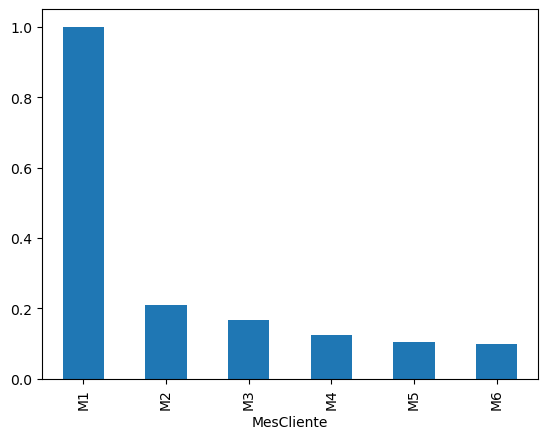

In [49]:
tasa_media.plot(kind = 'bar');

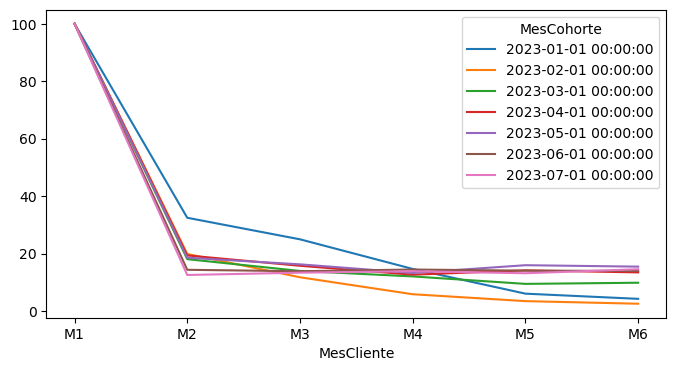

In [54]:
# ¿cómo varía la cantidad de clientes activos mes a mes para cada cohorte?
tabla_retencion.T.plot(kind='line', figsize=(8, 4));

### Cálculo de la tasa de retención global

In [51]:
# Tasa de retención global
# Calcular el total de clientes iniciales en todas las cohortes (M1 de todas las filas)
total_inicial_global = tabla_cohortes['M1'].sum()

# Calcular el total de clientes retenidos en el último mes (M6 en este caso)
total_retenidos_final = tabla_cohortes['M6'].sum()

# Calcular la tasa de retención global usando solo el último mes
tasa_retencion_global = total_retenidos_final / total_inicial_global
tasa_retencion_global

np.float64(0.09862880211596019)

## Código Cohortes unificado

In [58]:
# # Crear la columna 'MesTransaccion' a partir de 'Fecha' en formato Period (mes y año)
# productos['MesTransaccion'] = productos['Fecha'].dt.to_period('M')

# # Añadir el mes de cohorte
# productos['MesCohorte'] = productos.groupby('ID_Cliente')['MesTransaccion'].transform('min')

# # Eliminar registros de cohortes no completas
# resultados = productos[productos['MesCohorte'] <= '2023-07']

# # Transformar las variables Mes: a datetime
# resultados = resultados.copy()
# resultados['MesTransaccion'] = pd.to_datetime(resultados['MesTransaccion'].astype(str), format='%Y-%m')
# resultados['MesCohorte'] = pd.to_datetime(resultados['MesCohorte'].astype(str), format='%Y-%m')

# # Eliminar registros que no entran en el mes de cohorte de estudio
# resultados_filtrados = resultados[resultados['MesTransaccion'] <= resultados['MesCohorte'] + pd.DateOffset(months=5)]

# # Crear variable mes desde el punto de vista cliente
# resultados_filtrados = resultados_filtrados.copy()

# # Paso 1: Crear nuevas columnas temporales como Period[M] sin sobrescribir las originales
# mes_transaccion_period = resultados_filtrados['MesTransaccion'].dt.to_period('M')
# mes_cohorte_period = resultados_filtrados['MesCohorte'].dt.to_period('M')

# # Paso 2: Calcular la diferencia en meses entre las columnas temporales
# diferencia_meses = mes_transaccion_period - mes_cohorte_period

# # Paso 3: Crear la nueva columna 'MesCliente' con la diferencia calculada
# resultados_filtrados.loc[:, 'MesCliente'] = 'M' + diferencia_meses.apply(lambda x: str(x.n + 1))

# # Obtener tabla de cohortes
# # Crear la tabla pivotada de cohortes para el análisis
# tabla_cohortes = pd.pivot_table(
#     resultados_filtrados,
#     index='MesCohorte',
#     columns='MesCliente', # Permite ordenar las filas en los meses de cada cohorte
#     values='ID_Cliente',
#     aggfunc='nunique'  # Contar clientes únicos por cada cohorte y mes
# ).fillna(0).astype(int)  # Rellenar NaN con 0 y convertir a enteros

# # Calcular tabla de retención
# tabla_retencion = tabla_cohortes.div(tabla_cohortes['M1'], axis=0) * 100

# tabla_retencion = tabla_retencion.round(1)

